# Stanford CME 241 (Winter 2026) - Assignment 1

**Due: Friday, January 23 @ 11:59 PM PST on Gradescope.**

Assignment instructions:
- Make sure each of the subquestions have answers
- Ensure that group members indicate which problems they're in charge of
- Show work and walk through your thought process where applicable
- Empty code blocks are for your use, so feel free to create more under each section as needed
- Document code with light comments (i.e. 'this function handles visualization')

Submission instructions:
- When complete, fill out your publicly available GitHub repo file URL and group members below, then export or print this .ipynb file to PDF and upload the PDF to Gradescope.

*Link to this ipynb file in your public GitHub repo (replace below URL with yours):*

https://github.com/my-username/my-repo/assignment-file-name.ipynb

*Group members (replace below names with people in your group):*
- Person 1
- Person 2
- Person 3

## Imports

In [1]:
# fill in with Python code
import numpy as np
import matplotlib.pyplot as plt
from rl.distribution import Categorical
from rl.markov_process import FiniteMarkovProcess, NonTerminal, Terminal
from pprint import pprint


## Question 1: Snakes and Ladders (Led by ______)

In the classic childhood game of Snakes and Ladders, all players start to the left of square 1 (call this position 0) and roll a 6-sided die to represent the number of squares they can move forward. The goal is to reach square 100 as quickly as possible. Landing on the bottom rung of a ladder allows for an automatic free-pass to climb, e.g. square 4 sends you directly to 14; whereas landing on a snake's head forces one to slide all the way to the tail, e.g. square 34 sends you to 6. Note, this game can be viewed as a Markov Process, where the outcome is only depedent on the current state and not the prior trajectory. In this question, we will ask you to both formally describe the Markov Process that describes this game, followed by coding up a version of the game to get familiar with the RL-book libraries.


### Problem Statement

How can we model this problem with a Markov Process?

---

### Subquestions

#### Part (A): MDP Modeling

Formalize the state space of the Snakes and Ladders game. Don't forget to specify the terminal state!

---

#### Part (B): Transition Probabilities

Write out the structure of the transition probabilities. Feel free to abbreviate all squares that do not have a snake or ladder.

---

#### Part (C): Modeling the Game

Code up a `transition_map: Transition[S]` data structure to represent the transition probabilities of the Snakes and Ladders Markov Process so you can model the game as an instance of `FiniteMarkovProcess`. Use the `traces` method to create sampling traces, and plot the graph of the distribution of time steps to finish the game. Use the image provided for the locations of the snakes and ladders.

https://drive.google.com/file/d/1yhP242sG092Ico_WOPKrUp8jVJHbuGHH/view?usp=sharing

---

### Part (A) Answer

<span style="color:red">*The state space for this game are all the positions from 0 to 100. 0 is the initial start, 1 to 99 are non-terminal states, and 100 is the terminal state*</span>

### Part (B) Answer

<span style="color:red">*This game states form a stochastic matrix of size 101 x 101 (0 to 100 in rows/columns). Starting with simple states (no ladders/snakes), the probability from state x to state x+k for k ∈ {1,2,3,4,5,6} and x+k ≤ 100 is 1/6 for each k. For states near the end: P(95→96) = 1/6, P(95→97) = 1/6, P(95→98) = 1/6, P(95→99) = 1/6, P(95→100) = 2/6; P(96→97) = 1/6, P(96→98) = 1/6, P(96→99) = 1/6, P(96→100) = 3/6; P(97→98) = 1/6, P(97→99) = 1/6, P(97→100) = 4/6; P(98→99) = 1/6, P(98→100) = 5/6; P(99→100) = 1. In the case we land on a snake or ladder, then we just change the probability to go to where the snake tail/ladder top land. If we have the exact map of the game, the probabilities can be calculated as well.*</span>

### Part (C) Answer

{0: {38: 0.16666666666666669, 2: 0.16666666666666669, 3: 0.16666666666666669, 14: 0.16666666666666669, 5: 0.16666666666666669, 6: 0.16666666666666669},
 1: {2: 0.16666666666666669, 3: 0.16666666666666669, 14: 0.16666666666666669, 5: 0.16666666666666669, 6: 0.16666666666666669, 7: 0.16666666666666669},
 2: {3: 0.16666666666666669, 14: 0.16666666666666669, 5: 0.16666666666666669, 6: 0.16666666666666669, 7: 0.16666666666666669, 30: 0.16666666666666669},
 3: {14: 0.16666666666666669, 5: 0.16666666666666669, 6: 0.16666666666666669, 7: 0.16666666666666669, 30: 0.16666666666666669, 9: 0.16666666666666669},
 4: {5: 0.16666666666666669, 6: 0.16666666666666669, 7: 0.16666666666666669, 30: 0.16666666666666669, 9: 0.16666666666666669, 10: 0.16666666666666669},
 5: {6: 0.16666666666666669, 7: 0.16666666666666669, 30: 0.16666666666666669, 9: 0.16666666666666669, 10: 0.16666666666666669, 11: 0.16666666666666669},
 6: {7: 0.16666666666666669, 30: 0.16666666666666669, 9: 0.16666666666666669, 10: 0.1666

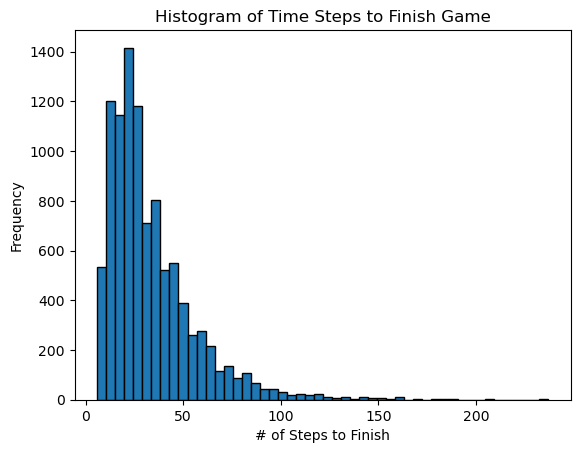

In [ ]:
snakes = {32:10, 36:6, 48:26, 63:18, 88:24, 95:56, 97:78}
ladders = {1:38, 4:14, 8:30, 21:42, 28:76, 50:67, 71:92, 80:99}

#function to check if a position has a ladder or snake
def check_snakes_ladders(position: int) -> int:
    if position in ladders:
        return ladders[position]
    elif position in snakes:
        return snakes[position]
    else:
        return position

#Create the transition map for the game. States 0-99 are non-terminal (0 is starting position, 1-99 are game squares), 
#and state 100 is terminal (winning state)
transition_map = {}

for state in range(100):  
    next_states = {}
    for die_roll in range(1, 7):
        next_pos = state + die_roll
        # If position is greater than 100, we go to 100 (this is the rule we used)
        if next_pos > 100:
            next_pos = 100
        # Apply snake or ladder if we land on one
        final_pos = check_snakes_ladders(next_pos)
        # Add probability 1/6 for this outcome
        next_states[final_pos] = next_states.get(final_pos, 0) + 1/6 #use get in case the key doesn't exist yet
    # Convert to Categorical distribution from the rl.distribution library
    transition_map[state] = Categorical(next_states)

# check if transition map is correct
pprint(transition_map) 

# Create the FiniteMarkovProcess from the transition map
finite_markov_process = FiniteMarkovProcess(transition_map)

# run 10000 traces and count steps to finish
num_traces = 0
time_steps = []
max_traces = 10000
for trace in finite_markov_process.traces(Categorical({NonTerminal(0): 1.0})):
  if num_traces >= max_traces:
    break
  num_traces += 1
  steps = 0
  for state in trace:
    if isinstance(state, Terminal):
      break
    steps += 1
  time_steps.append(steps)

# Plot the distribution of time steps to finish
plt.hist(time_steps, bins=50, edgecolor='black')
plt.xlabel('# of Steps to Finish')
plt.ylabel('Frequency')
plt.title(f'Histogram of Time Steps to Finish Game')
plt.show()

# print(f"Mean steps needed to finish: {np.mean(time_steps):.2f}")
# print(f"Median steps needed to finish: {np.median(time_steps):.2f}")
# print(f"Standard deviation: {np.std(time_steps):.2f}")


## Question 2: Markov Decision Processes (Led by ______)

Consider an MDP with an infinite set of states ${S} = \{1,2,3,\ldots \}$. The start state is $s=1$. Each state $s$ allows a continuous set of actions $a \in [0,1]$. The transition probabilities are given by:
$$\mathbb{P}[s+1 \mid s, a] = a, \mathbb{P}[s \mid s, a] = 1 - a \text{ for all } s \in S \text{ for all } a \in [0,1]$$
For all states $s \in {S}$ and actions $a \in [0,1]$, transitioning from $s$ to $s+1$ results in a reward of $1-a$ and transitioning from $s$ to $s$ results in a reward of $1+a$. The discount factor $\gamma=0.5$.

### Problem Statement

How can we derive a mathematical formulation for the value function and the optimal policy? And how do those functions change when we modify the action space?

---

### Subquestions

#### Part (A): Optimal Value Function  

Using the MDP Bellman Optimality Equation, calculate the Optimal Value Function $V^*(s)$ for all $s \in {S}$. Given $V^*(s)$, what is the optimal action, $a^*$, that maximizes the optimal value function?

---

#### Part (B): Optimal Policy  

Calculate an Optimal Deterministic Policy $\pi^*(s)$ for all $s \in {S}$.

---

#### Part (C): Changing the Action Space  

Let's assume that we modify the action space such that instead of $a \in [0,1]$ for all states, we restrict the action space to $a \in \left[0,\frac{1}{s}\right]$ for state $s$. This means that higher states have more restricted action spaces. How does this constraint affect:

- The form of the Bellman optimality equation?
- The optimal value function, $V^*(s)$?
- The structure of the optimal policy, $\pi^*(s)$?

---

# Problem 2

## Part A

- Action space:

  $$
  a \in [0,1]
  $$

- Transitions:
  - With probability \( a \): transition to \( s+1 \) and get reward \( 1 - a \)
  - With probability \( 1 - a \): stay in \( s \) and get reward \( 1 + a \)


Expected Immediate Reward

$$
\begin{aligned}
R(s,a)
&= a(1 - a) + (1 - a)(1 + a) \\
&= (a - a^2) + (1 - a^2) \\
&= 1 + a - 2a^2
\end{aligned}
$$


Bellman Optimality Equation

$$
V^*(s)
= \max_{a \in [0,1]}
\Big[
R(s,a)
+ \gamma \big( a V^*(s+1) + (1-a)V^*(s) \big)
\Big]
$$

Substitute R(s,a) and gamma = 0.5:

$$
V^*(s)
= \max_{a \in [0,1]}
\Big[
1 + a - 2a^2
+ \tfrac{1}{2} \big( a V^*(s+1) + (1-a)V^*(s) \big)
\Big]
$$

Since the reward does not depend on the state,

$$
V^*(s) = V^*(s+1) = V^*
$$

Thus:

$$
\begin{aligned}
V^*
&= \max_{a \in [0,1]}
\Big[
1 + a - 2a^2
+ \tfrac{1}{2} (a V^* + (1-a)V^*)
\Big] \\
&= \max_{a \in [0,1]}
\Big[
1 + a - 2a^2 + \tfrac{1}{2}V^*
\Big]
\end{aligned}
$$

$$
V^* - \tfrac{1}{2}V^* = \max_{a \in [0,1]} \big[ 1 + a - 2a^2 \big]
$$

$$
V^* = 2 \max_{a \in [0,1]} \big[ 1 + a - 2a^2 \big]
$$


$$
V^* = \max_{a \in [0,1]} \big[ 2 + 2a - 4a^2 \big]
$$

take the derivative and maximumze over a: 

$$
\frac{d}{da}(2 + 2a - 4a^2) = 2 - 8a
$$

$$
2 - 8a = 0 \quad \Rightarrow \quad a^* = \tfrac{1}{4}
$$

$$
\begin{aligned}
V^*
&= 2 \Big( 1 + \tfrac{1}{4} - 2(\tfrac{1}{4})^2 \Big) \\
&= 2 \Big( 1.25 - 0.125 \Big) \\
&= 2.25
\end{aligned}
$$

## Part B: Optimal Policy

From Part A, the optimal action is 
$$
\
a^* = \tfrac{1}{4}
\quad \text{for all } s \in \mathcal{S}
$$

## Part C: Modified Action Space


$$
a \in \left[0, \tfrac{1}{s} \right]
$$

The Bellman Equation becomes

$$
V^*(s)
= \max_{a \in [0,1/s]}
\Big[
1 + 2a - 2a^2
+ \tfrac{1}{2} \big( a V^*(s+1) + (1-a)V^*(s) \big)
\Big]
$$

Rearranging:

$$
V^*(s) - \tfrac{1}{2}(1-a)V^*(s)
= 1 + a - 2a^2 + \tfrac{1}{2} a V^*(s+1)
$$

$$
\left(1 - \tfrac{1}{2}(1-a)\right)V^*(s)
= 1 + a - 2a^2 + \tfrac{1}{2} a V^*(s+1)
$$

$$
\
V^*(s)
= \max_{a \in [0,1/s]}
\frac{2(1 + a - 2a^2) + a V^*(s+1)}{1 + a}
$$

unlike in parts a and b, each state actions will be different, thus as s goes to infiniti, a goes to zero, then we will stay in the same sate with reward = 1+a = 1.

$$
\
V^*(s)
= 2, a->0,s->0
$$

The optimizal policy will now be dtermined based on the sate we are in, if \( s < 5\): optimal policy or action is
  $$
  a^* = \tfrac{1}{4}
  $$
  
For \( s >= 5\): the optimal policy or action is

  $$
  a^* = \tfrac{1}{s}
  $$


## Question 3: Frog in a Pond (Led by ______)

Consider an array of $n+1$ lilypads on a pond, numbered $0$ to $n$. A frog sits on a lilypad other than the lilypads numbered $0$ or $n$. When on lilypad $i$ ($1 \leq i \leq n-1$), the frog can croak one of two sounds: **A** or **B**.

- If it croaks **A** when on lilypad $i$ ($1 \leq i \leq n-1$):
  - It is thrown to lilypad $i-1$ with probability $\frac{i}{n}$.
  - It is thrown to lilypad $i+1$ with probability $\frac{n-i}{n}$.
  
- If it croaks **B** when on lilypad $i$ ($1 \leq i \leq n-1$):
  - It is thrown to one of the lilypads $0, \ldots, i-1, i+1, \ldots, n$ with uniform probability $\frac{1}{n}$.

A snake, perched on lilypad $0$, will eat the frog if it lands on lilypad $0$. The frog can escape the pond (and hence, escape the snake!) if it lands on lilypad $n$.

### Problem Statement

What should the frog croak when on each of the lilypads $1, 2, \ldots, n-1$, in order to maximize the probability of escaping the pond (i.e., reaching lilypad $n$ before reaching lilypad $0$)?

Although there are multiple ways to solve this problem, we aim to solve it by modeling it as a **Markov Decision Process (MDP)** and identifying the **Optimal Policy**.

---

### Subquestions

#### Part (A): MDP Modeling

Express the frog-escape problem as an MDP using clear mathematical notation by defining the following components:

- **State Space**: Define the possible states of the MDP.
- **Action Space**: Specify the actions available to the frog at each state.
- **Transition Function**: Describe the probabilities of transitioning between states for each action.
- **Reward Function**: Specify the reward associated with the states and transitions.

---

#### Part (B): Python Implementation

There is starter code below to solve this problem programatically. Fill in each of the $6$ `TODO` areas in the code. As a reference for the transition probabilities and rewards, you can make use of the example in slide 16/31 from the following slide deck: https://github.com/coverdrive/technical-documents/blob/master/finance/cme241/Tour-MP.pdf.

Write Python code that:

- Models this MDP.
- Solves the **Optimal Value Function** and the **Optimal Policy**.

Feel free to use/adapt code from the textbook. Note, there are other libraries that are needed to actually run this code, so running it will not do anything. Just fill in the code so that it could run assuming that the other libraries are present.

---

#### Part (C): Visualization and Analysis

What patterns do you observe for the **Optimal Policy** as you vary $n$ from $3$ to $25$? When the frog is on lilypad $13$ (with $25$ total), what action should the frog take? Is this action different than the action the frog should take if it is on lilypad $1$?

---

### Part (A) Answer

#### State Space:  

<span style="color:red">*fill in*</span>

#### Action Space:  

<span style="color:red">*fill in*</span>

#### Transition Function:  

<span style="color:red">*fill in*</span>

#### Reward Function:  

<span style="color:red">*fill in*</span>

### Part (B) Answer

In [10]:
MDPRefined = dict
def get_lily_pads_mdp(n: int) -> MDPRefined:
    data = {
        i: {
            'A': {
                i - 1: i / n, # TODO: fill in with the correct transition probabilities
                i + 1: (n - i) / n, # TODO: fill in with the correct transition probabilities
            },
            'B': {
                j: 1 / n 
                for j in list(range(0,i)) + list(range(i+1,n+1)) # TODO: fill in with the correct transition probabilities
            }
        } for i in range(1, n)
    }
    data[0] = {} # TODO: this is the initial state, so what would be the correct transition probabilities? Terminal state - no transitions
    data[n] = {} # TODO: similarly, this is the terminal state, so what would be the correct transition probabilities? terminal state - no transitions

    gamma = 1.0
    return MDPRefined(data, gamma)

Mapping = dict
def direct_bellman(n: int) -> Mapping[int, float]:
    vf = [0.5] * (n + 1)
    vf[0] = 0.
    vf[n] = 0.
    tol = 1e-8
    epsilon = tol * 1e4
    # get the mdp data
    mdp_data = get_lily_pads_mdp(n) 
    while epsilon >= tol:
        old_vf = [v for v in vf]
        for i in range(1, n):
            v_a = mdp_data[i]['A'][i - 1] * vf[i - 1] + mdp_data[i]['A'][i + 1] * vf[i + 1]
            v_b = sum(mdp_data[i]['B'][j] * vf[j] for j in mdp_data[i]['B'].keys())
            vf[i] = max(v_a, v_b)
        epsilon = max(abs(old_vf[i] - v) for i, v in enumerate(vf))
    return {v: f for v, f in enumerate(vf)}

### Part (C) Answer

<span style="color:red">*fill in*</span>

## Question 4: Manual Value Iteration (Led by ______)

Consider a simple MDP with ${S} = \{s_1, s_2, s_3\}, {T} = \{s_3\}, {A} = \{a_1, a_2\}$. The State Transition Probability function  
$${P}: {N} \times {A} \times {S} \rightarrow [0, 1]$$  
is defined as:  
$${P}(s_1, a_1, s_1) = 0.25, {P}(s_1, a_1, s_2) = 0.65, {P}(s_1, a_1, s_3) = 0.1$$  
$${P}(s_1, a_2, s_1) = 0.1, {P}(s_1, a_2, s_2) = 0.4, {P}(s_1, a_2, s_3) = 0.5$$  
$${P}(s_2, a_1, s_1) = 0.3, {P}(s_2, a_1, s_2) = 0.15, {P}(s_2, a_1, s_3) = 0.55$$  
$${P}(s_2, a_2, s_1) = 0.25, {P}(s_2, a_2, s_2) = 0.55, {P}(s_2, a_2, s_3) = 0.2$$  

The Reward Function  
$${R}: {N} \times {A} \rightarrow \mathbb{R}$$  
is defined as:  
$${R}(s_1, a_1) = 8.0, {R}(s_1, a_2) = 10.0$$  
$${R}(s_2, a_1) = 1.0, {R}(s_2, a_2) = -1.0$$  

Assume a discount factor of $\gamma = 1$.

### Problem Statement

Your task is to determine an Optimal Deterministic Policy **by manually working out** (not with code) the first two iterations of the Value Iteration algorithm.

---

### Subquestions

#### Part (A): 2 Iterations

1. Initialize the Value Function for each state to be its $\max$ (over actions) reward, i.e., we initialize the Value Function to be $v_0(s_1) = 10.0, v_0(s_2) = 1.0, v_0(s_3) = 0.0$. Then manually calculate $q_k(\cdot, \cdot)$ and $v_k(\cdot)$ from $v_{k - 1}(\cdot)$ using the Value Iteration update, and then calculate the greedy policy $\pi_k(\cdot)$ from $q_k(\cdot, \cdot)$ for $k = 1$ and $k = 2$ (hence, 2 iterations).

---

#### Part (B): Argument

1. Now argue that $\pi_k(\cdot)$ for $k > 2$ will be the same as $\pi_2(\cdot)$. *Hint*: You can make the argument by examining the structure of how you get $q_k(\cdot, \cdot)$ from $v_{k-1}(\cdot)$. With this argument, there is no need to go beyond the two iterations you performed above, and so you can establish $\pi_2(\cdot)$ as an Optimal Deterministic Policy for this MDP.

---

#### Part (C): Policy Evaluation

1. Using the policy $\pi_2(\cdot)$, compute the exact value function $V^{\pi_2}(s)$ for all $s\in S$.

---

#### Part (D): Sensitivity Analysis

Assume the reward for $R(s_1, a_2)$ is modified to $11.0$ instead of $10.0$.

1. Perform one iteration of Value Iteration starting from the initialized value function $v_0(s)$, where $v_0(s)$ remains the same as in the original problem.
2. Determine whether this change impacts the Optimal Deterministic Policy $\pi(\cdot)$. If it does, explain why.

---

### Part (A) Answer

<span style="color:red">*fill in*</span>

### Part (B) Answer:  

<span style="color:red">*fill in*</span>

### Part (C) Answer:  

<span style="color:red">*fill in*</span>

### Part (D) Answer

#### Value Iteration:  

<span style="color:red">*fill in*</span>

#### Optimal Deterministic Policy:  

<span style="color:red">*fill in*</span>

## Question 5: Fixed-Point and Policy Evaluation True/False Questions (Led by ______)

### Recall Section: Key Formulas and Definitions

#### Bellman Optimality Equation
The Bellman Optimality Equation for state-value functions is:
$$
V^*(s) = \max_a \left[ R(s, a) + \gamma \sum_{s'} P(s, a, s') V^*(s') \right].
$$
For action-value functions:
$$
Q^*(s, a) = R(s, a) + \gamma \sum_{s'} P(s, a, s') \max_{a'} Q^*(s', a').
$$

#### Contraction Property
The Bellman Policy Operator $B^\pi$ is a contraction under the $L^\infty$-norm:
$$
\|B^\pi(X) - B^\pi(Y)\|_\infty \leq \gamma \|X - Y\|_\infty.
$$
This guarantees convergence to a unique fixed point.

#### Policy Iteration
Policy Iteration alternates between:
1. **Policy Evaluation**: Compute $V^\pi$ for the current policy $\pi$.
2. **Policy Improvement**: Generate a new policy $\pi'$ by setting:
   $$
   \pi'(s) = \arg\max_a \left[ R(s, a) + \gamma \sum_{s'} P(s, a, s') V^\pi(s') \right].
   $$

#### Discounted Return
The discounted return from time step $t$ is:
$$
G_t = \sum_{i=t+1}^\infty \gamma^{i-t-1} R_i,
$$
where $\gamma \in [0, 1)$ is the discount factor.

### True/False Questions (Provide Justification)

1. **True/False**: If $Q^\pi(s, a) = 5$, $P(s, a, s') = 0.5$ for $s' \in \{s_1, s_2\}$, and the immediate reward $R(s, a)$ increases by $2$, the updated action-value function $Q^\pi(s, a)$ also increases by $2$.


---

2. **True/False**: For a discount factor $\gamma = 0.9$, the discounted return for rewards $R_1 = 5, R_2 = 3, R_3 = 1$ is greater than $6$.

---

3. **True/False**: The Bellman Policy Operator $B^\pi(V) = R^\pi + \gamma P^\pi \cdot V$ satisfies the contraction property for all $\gamma \in [0, 1)$, ensuring a unique fixed point.

---

4. **True/False**: In Policy Iteration, the Policy Improvement step guarantees that the updated policy $\pi'$ will always perform strictly better than the previous policy $\pi$.

---

5. **True/False**: If $Q^\pi(s, a) = 10$ for all actions $a$ in a state $s$, then the corresponding state-value function $V^\pi(s) = 10$, regardless of the policy $\pi$.

---

6. **True/False**: The discounted return $G_t = \sum_{i=t+1}^\infty \gamma^{i-t-1} R_i$ converges to a finite value for any sequence of bounded rewards if $\gamma < 1$.

---

### Answers (Provide justification, brief explanations are fine)

#### Question 1:  

<span style="color:red">*fill in*</span>

#### Question 2:  

<span style="color:red">*fill in*</span>

#### Question 3:  

<span style="color:red">*fill in*</span>

#### Question 4:  

<span style="color:red">*fill in*</span>

#### Question 5:  

<span style="color:red">*fill in*</span>

#### Question 6:  

<span style="color:red">*fill in*</span>